In [4]:
## import data & main liabraries 

In [5]:
import pandas as pd
import numpy as np

np.random.seed(42)
n_rows = 6000

categories = {
    "Beverages": ["Espresso", "Latte", "Cappuccino", "Cold Brew", "Mocha"],
    "Food": ["Croissant", "Muffin", "Bagel", "Sandwich", "Cookie"],
    "Merchandise": ["Mug", "Tumbler", "Coffee Beans Bag", "Gift Card"]
}
regions = ["Central", "East", "West", "South"]
customer_types = ["Member", "Non-Member", "Walk-in"]
stores = {
    "Central": ["Downtown", "Midtown"], "East": ["Eastside", "Riverside"],
    "West": ["Westend", "Hillview"], "South": ["Southgate", "Lakeside"]
}

date_range = pd.date_range("2015-01-01", "2018-12-31", freq="D")
rows = []
for _ in range(n_rows):
    category = np.random.choice(list(categories.keys()), p=[0.55, 0.30, 0.15])
    subcategory = np.random.choice(categories[category])
    region = np.random.choice(regions)
    store = np.random.choice(stores[region])
    customer = np.random.choice(customer_types, p=[0.4, 0.35, 0.25])
    date = np.random.choice(date_range)
    base_price = {"Beverages": np.random.uniform(3, 7), "Food": np.random.uniform(2.5, 6),
                  "Merchandise": np.random.uniform(8, 25)}[category]
    qty = np.random.randint(1, 5)
    unit_price = round(base_price, 2)
    sales = round(unit_price * qty, 2)
    cost = round(sales * np.random.uniform(0.35, 0.55), 2)
    profit = round(sales - cost, 2)
    rows.append([date, category, subcategory, region, store, customer, qty, unit_price, sales, profit])

df = pd.DataFrame(rows, columns=["OrderDate", "Category", "SubCategory", "Region", "Store",
                                   "CustomerType", "Quantity", "UnitPrice", "Sales", "Profit"])
df = df.sort_values("OrderDate").reset_index(drop=True)
df.insert(0, "OrderID", range(1001, 1001 + len(df)))
df.to_csv("coffee_shop_sales.csv", index=False)
print("Saved! Rows:", len(df))

Saved! Rows: 6000


In [6]:
## KPI 

In [7]:
total_sales = df["Sales"].sum()
total_orders = df["OrderID"].nunique()
avg_sales = df["Sales"].mean()
total_profit = df["Profit"].sum()

print(f"Total Sales: ${total_sales:,.0f}")
print(f"Total Orders: {total_orders:,}")
print(f"Avg Sale: ${avg_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.0f}")

Total Sales: $98,039
Total Orders: 6,000
Avg Sale: $16.34
Total Profit: $53,869


In [8]:
## Dashboard

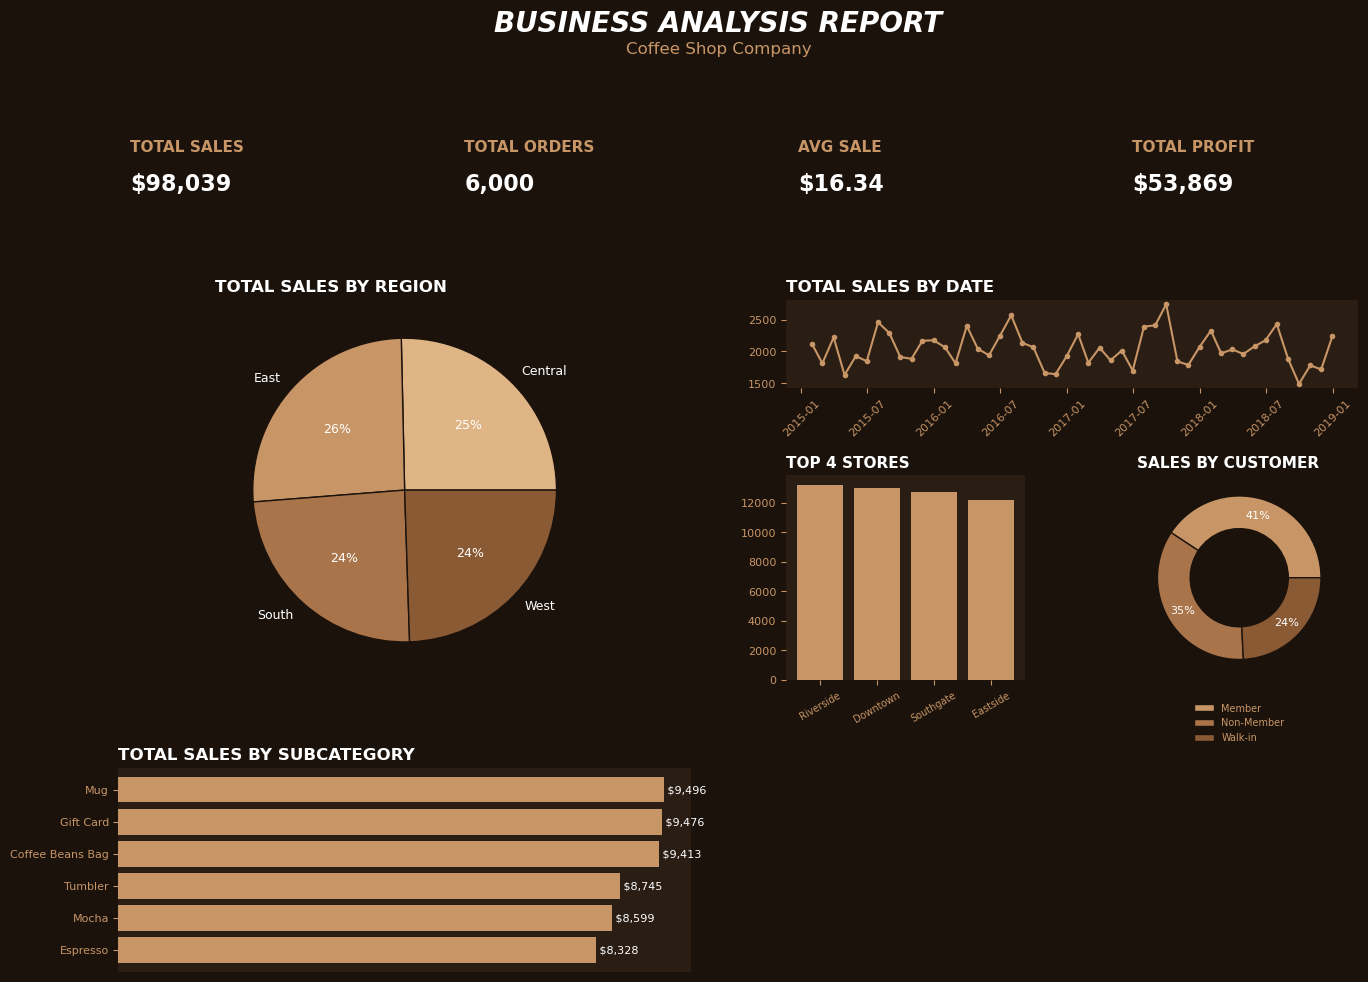

In [9]:
plt.rcParams["font.family"] = "DejaVu Sans"

fig = plt.figure(figsize=(16, 11), facecolor="#1b120c")
gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.6, wspace=0.4,
                        height_ratios=[0.6, 0.6, 1.4, 1.4])

CREAM = "#c89666"   # primary accent (caramel brown)
DARK = "#1b120c"    # near-black espresso brown background
PANEL = "#2a1d14"   # dark roasted brown panel background
BROWN_SHADES = ["#e0b585", "#c89666", "#a9744a", "#8a5a35", "#6b4226", "#4a2c18"]

def style_panel(ax):
    ax.set_facecolor(PANEL)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors=CREAM, labelsize=8)
    return ax

# KPI cards (row 0)
kpis = [
    ("TOTAL SALES", f"${total_sales:,.0f}"),
    ("TOTAL ORDERS", f"{total_orders:,}"),
    ("AVG SALE", f"${avg_sales:,.2f}"),
    ("TOTAL PROFIT", f"${total_profit:,.0f}"),
]
for i, (label, value) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor(PANEL)
    ax.axis("off")
    ax.text(0.05, 0.7, label, color=CREAM, fontsize=11, fontweight="bold")
    ax.text(0.05, 0.25, value, color="white", fontsize=16, fontweight="bold")

# Sales by Region (pie)
ax_pie = fig.add_subplot(gs[1:3, 0:2])
region_sales = df.groupby("Region")["Sales"].sum()
ax_pie.pie(region_sales, labels=region_sales.index,
           autopct="%1.0f%%", colors=BROWN_SHADES[:4],
           textprops={"color": "white", "fontsize": 9}, wedgeprops={"edgecolor": DARK})
ax_pie.set_title("TOTAL SALES BY REGION", color="white", fontsize=12, fontweight="bold", loc="left")
ax_pie.set_facecolor(DARK)

# Sales by SubCategory (horizontal bar)
ax_bar = fig.add_subplot(gs[3, 0:2])
style_panel(ax_bar)
sub_sales = df.groupby("SubCategory")["Sales"].sum().sort_values(ascending=True).tail(6)
ax_bar.barh(sub_sales.index, sub_sales.values, color=CREAM)
for i, v in enumerate(sub_sales.values):
    ax_bar.text(v, i, f" ${v:,.0f}", color="white", va="center", fontsize=8)
ax_bar.set_title("TOTAL SALES BY SUBCATEGORY", color="white", fontsize=12, fontweight="bold", loc="left")
ax_bar.set_xticks([])

# Sales by Date (line)
ax_line = fig.add_subplot(gs[1, 2:4])
monthly = df.set_index("OrderDate").resample("ME")["Sales"].sum()
ax_line.plot(monthly.index, monthly.values, color=CREAM, marker="o", markersize=3)
style_panel(ax_line)
ax_line.set_title("TOTAL SALES BY DATE", color="white", fontsize=12, fontweight="bold", loc="left")
ax_line.tick_params(axis="x", rotation=45)

# Top stores (bar)
ax_state = fig.add_subplot(gs[2, 2])
style_panel(ax_state)
top_stores = df.groupby("Store")["Sales"].sum().sort_values(ascending=False).head(4)
ax_state.bar(top_stores.index, top_stores.values, color=CREAM)
ax_state.set_title("TOP 4 STORES", color="white", fontsize=11, fontweight="bold", loc="left")
ax_state.tick_params(axis="x", rotation=30, labelsize=7)

# Sales by Customer Type (donut)
ax_donut = fig.add_subplot(gs[2, 3])
cust_sales = df.groupby("CustomerType")["Sales"].sum()
wedges, _, _ = ax_donut.pie(cust_sales, autopct="%1.0f%%", pctdistance=0.8,
                             colors=BROWN_SHADES[1:4],
                             textprops={"color": "white", "fontsize": 8},
                             wedgeprops={"width": 0.4, "edgecolor": DARK})
ax_donut.set_title("SALES BY CUSTOMER", color="white", fontsize=11, fontweight="bold", loc="left")
ax_donut.legend(wedges, cust_sales.index, loc="lower center", bbox_to_anchor=(0.5, -0.35),
                 ncol=1, fontsize=7, frameon=False, labelcolor=CREAM)
ax_donut.set_facecolor(DARK)

# Title bar
fig.text(0.5, 0.965, "BUSINESS ANALYSIS REPORT", ha="center", color="white",
          fontsize=20, fontweight="bold", fontstyle="italic")
fig.text(0.5, 0.945, "Coffee Shop Company", ha="center", color=CREAM, fontsize=12)

plt.savefig("coffee_dashboard.png", dpi=150, facecolor=DARK, bbox_inches="tight")
plt.show()